# 5단계 — 성능 평가 및 시각화

**기준 실험**: v2 (전체기간 + Return 피처)  
**산출물**: Confusion Matrix, ROC Curve, 예측 방향 시각화, Feature Importance

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

PROCESSED_DIR = Path("../data/processed")
RAW_DIR       = Path("../data/raw")
MODEL_DIR     = Path("../models/v2")
RESULTS_DIR   = Path("../reports/results/v2")
FIG_DIR       = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["lr", "xgb", "mlp", "tcn"]
MODEL_NAMES = {"lr": "LR", "xgb": "XGBoost", "mlp": "MLP", "tcn": "Dilated TCN"}
COLORS = {"lr": "#1f77b4", "xgb": "#ff7f0e", "mlp": "#2ca02c", "tcn": "#d62728"}

# 예측 결과 로드
preds = {}
for m in MODELS:
    preds[m] = pd.read_csv(RESULTS_DIR / f"{m}_test_predictions.csv", index_col=0, parse_dates=True)

metrics = pd.read_csv(RESULTS_DIR / "model_metrics.csv")
print("데이터 로드 완료")
print(metrics.to_string(index=False))

데이터 로드 완료
     model  accuracy  precision  recall     f1  roc_auc
        LR     52.89     0.5268  1.0000 0.6901   0.5763
   XGBoost     52.00     0.5227  0.9746 0.6805   0.4955
       MLP     52.44     0.5244  1.0000 0.6880   0.5570
DilatedTCN     54.63     0.5400  0.9908 0.6990   0.5728


## 1. 모델 성능 비교표

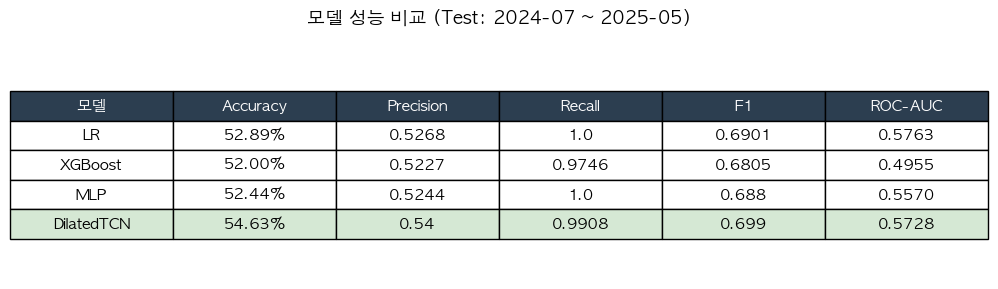

In [2]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

display_metrics = metrics.copy()
display_metrics["accuracy"] = display_metrics["accuracy"].apply(lambda x: f"{x:.2f}%")
display_metrics["roc_auc"]  = display_metrics["roc_auc"].apply(lambda x: f"{x:.4f}")
display_metrics.columns     = ["모델", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

table = ax.table(
    cellText=display_metrics.values,
    colLabels=display_metrics.columns,
    cellLoc="center", loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# 헤더 스타일
for j in range(len(display_metrics.columns)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# 최고 Accuracy 행 강조 (TCN)
best_row = metrics["accuracy"].idxmax() + 1
for j in range(len(display_metrics.columns)):
    table[best_row, j].set_facecolor("#d5e8d4")

plt.title("모델 성능 비교 (Test: 2024-07 ~ 2025-05)", fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_metrics_table.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. ROC Curve

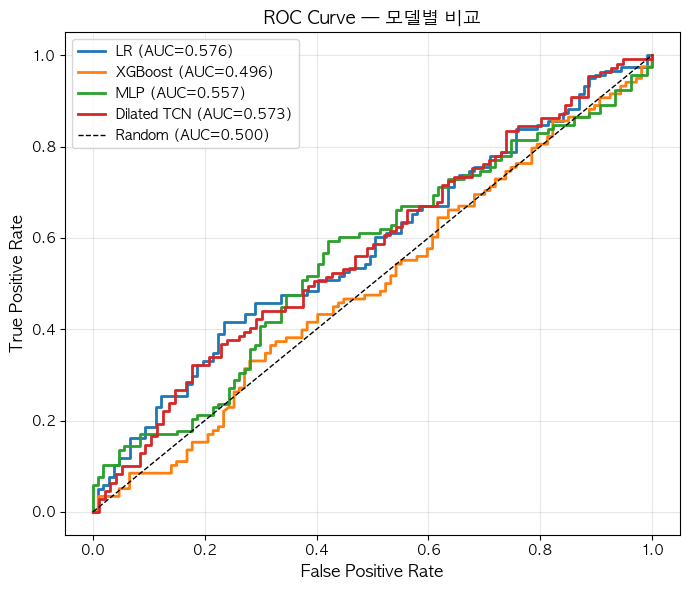

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))

for m in MODELS:
    df = preds[m]
    fpr, tpr, _ = roc_curve(df["y_true"], df["y_prob"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[m], linewidth=2,
            label=f"{MODEL_NAMES[m]} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — 모델별 비교", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Confusion Matrix

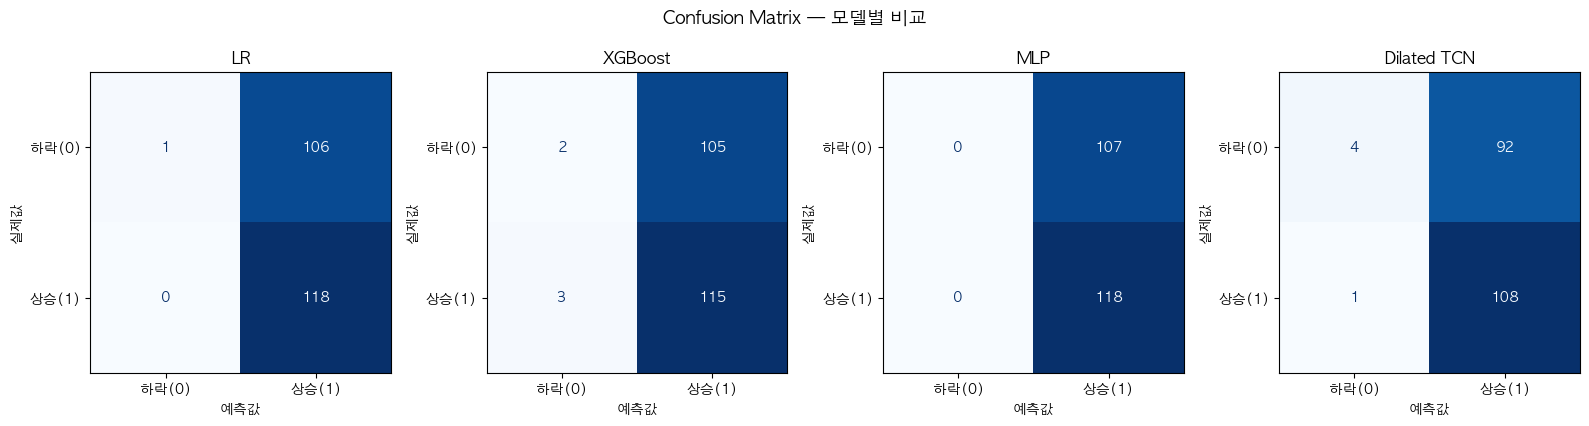

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, m in zip(axes, MODELS):
    df = preds[m]
    cm = confusion_matrix(df["y_true"], df["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["하락(0)", "상승(1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(MODEL_NAMES[m], fontsize=12)
    ax.set_xlabel("예측값")
    ax.set_ylabel("실제값")

plt.suptitle("Confusion Matrix — 모델별 비교", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 실제 주가 + 예측 방향 시각화

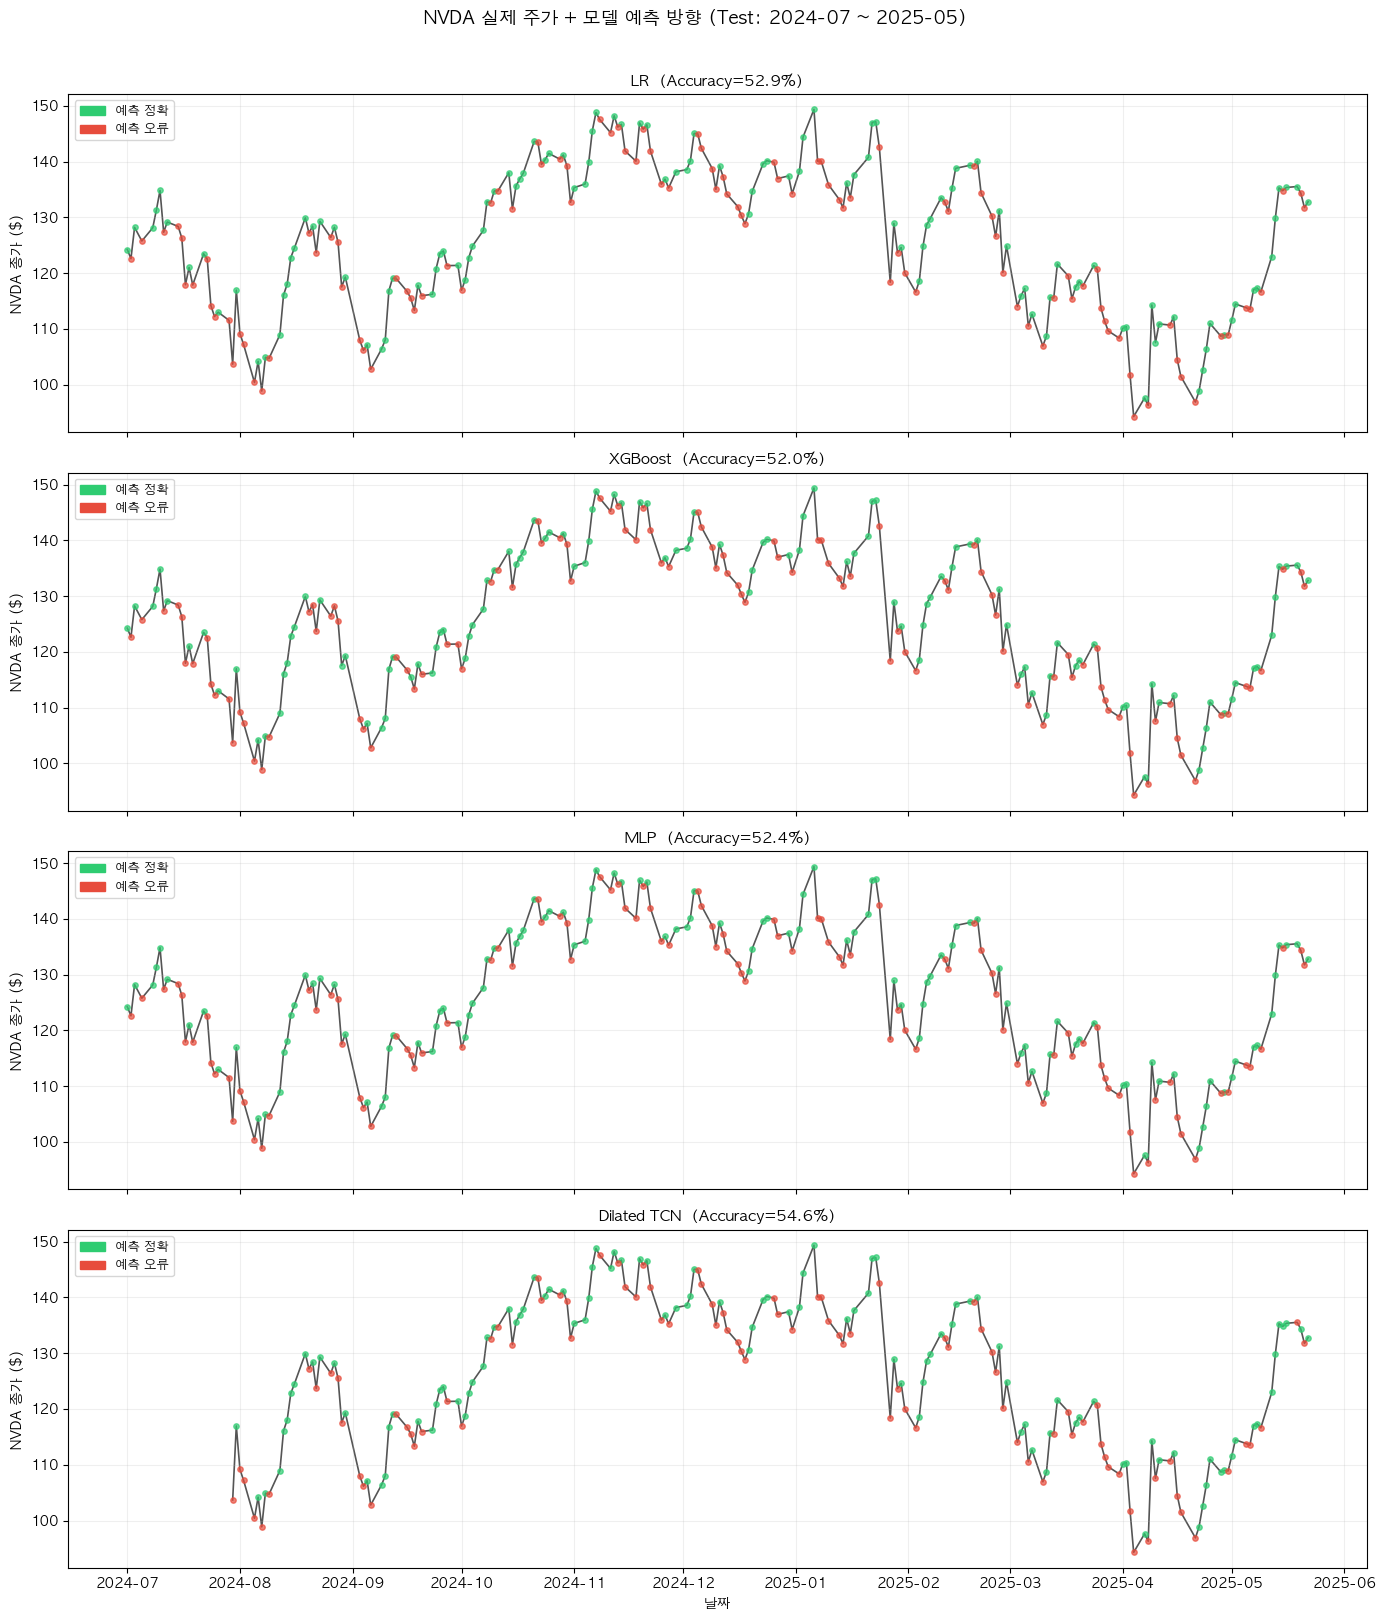

In [5]:
# 실제 NVDA 종가 로드
prices = pd.read_csv(RAW_DIR / "prices_raw.csv", index_col=0, parse_dates=True)
nvda_test = prices.loc[preds["lr"].index, "NVDA"]

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for ax, m in zip(axes, MODELS):
    df = preds[m].copy()
    df["nvda"] = nvda_test
    df["correct"] = df["y_true"] == df["y_pred"]

    # 주가 선
    ax.plot(df.index, df["nvda"], color="#555555", linewidth=1.2, zorder=1)

    # 맞춘 날 (초록), 틀린 날 (빨강)
    correct   = df[df["correct"]]
    incorrect = df[~df["correct"]]
    ax.scatter(correct.index,   correct["nvda"],   color="#2ecc71", s=15, zorder=2, alpha=0.7)
    ax.scatter(incorrect.index, incorrect["nvda"], color="#e74c3c", s=15, zorder=2, alpha=0.7)

    acc = (df["correct"].mean() * 100)
    ax.set_title(f"{MODEL_NAMES[m]}  (Accuracy={acc:.1f}%)", fontsize=11)
    ax.set_ylabel("NVDA 종가 ($)")
    ax.grid(alpha=0.2)

    patch_correct   = mpatches.Patch(color="#2ecc71", label="예측 정확")
    patch_incorrect = mpatches.Patch(color="#e74c3c", label="예측 오류")
    ax.legend(handles=[patch_correct, patch_incorrect], fontsize=9, loc="upper left")

axes[-1].set_xlabel("날짜")
plt.suptitle("NVDA 실제 주가 + 모델 예측 방향 (Test: 2024-07 ~ 2025-05)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_price_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Importance (LR 계수 + XGBoost)

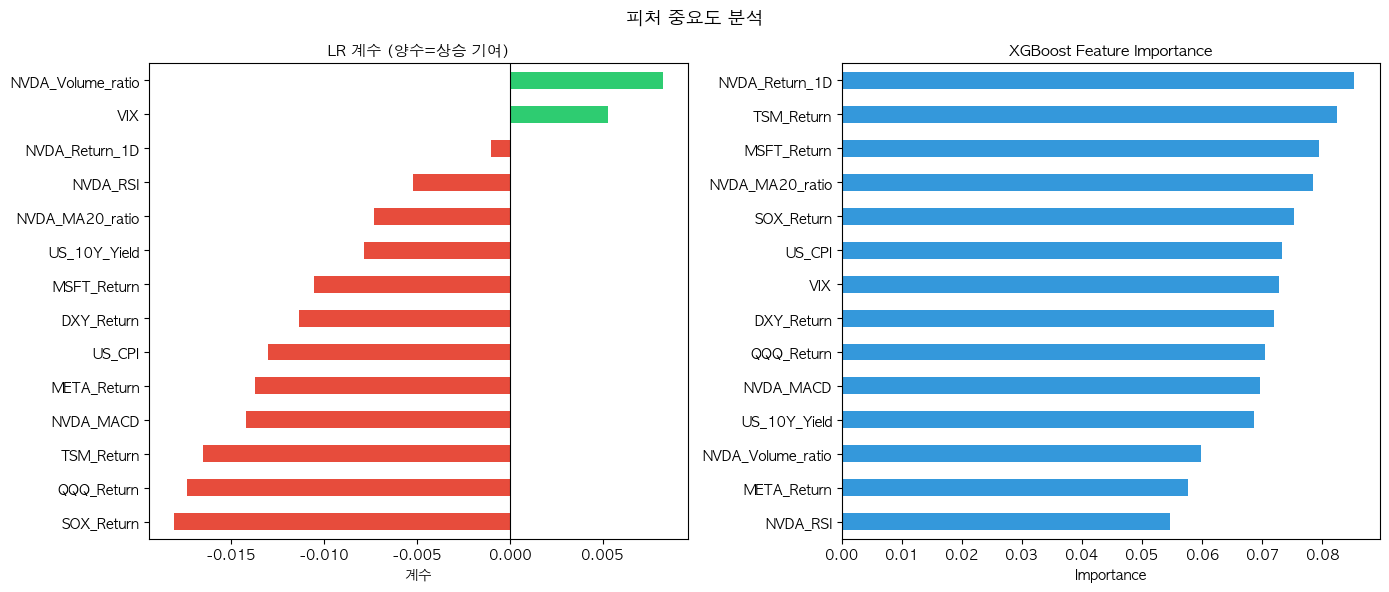

In [6]:
FEATURE_COLS = [
    "NVDA_Return_1D", "NVDA_MA20_ratio", "NVDA_Volume_ratio", "NVDA_RSI", "NVDA_MACD",
    "SOX_Return", "TSM_Return",
    "US_10Y_Yield", "QQQ_Return", "DXY_Return", "US_CPI",
    "VIX",
    "MSFT_Return", "META_Return",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LR 계수
lr_pipe = joblib.load(MODEL_DIR / "lr_model.joblib")
coef = lr_pipe.named_steps["model"].coef_[0]
coef_df = pd.Series(coef, index=FEATURE_COLS).sort_values()
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in coef_df]
coef_df.plot(kind="barh", ax=axes[0], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("LR 계수 (양수=상승 기여)", fontsize=11)
axes[0].set_xlabel("계수")

# XGBoost Feature Importance
xgb_model = joblib.load(MODEL_DIR / "xgb_model.joblib")
importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values()
importance.plot(kind="barh", ax=axes[1], color="#3498db")
axes[1].set_title("XGBoost Feature Importance", fontsize=11)
axes[1].set_xlabel("Importance")

plt.suptitle("피처 중요도 분석", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 실험별 성능 비교

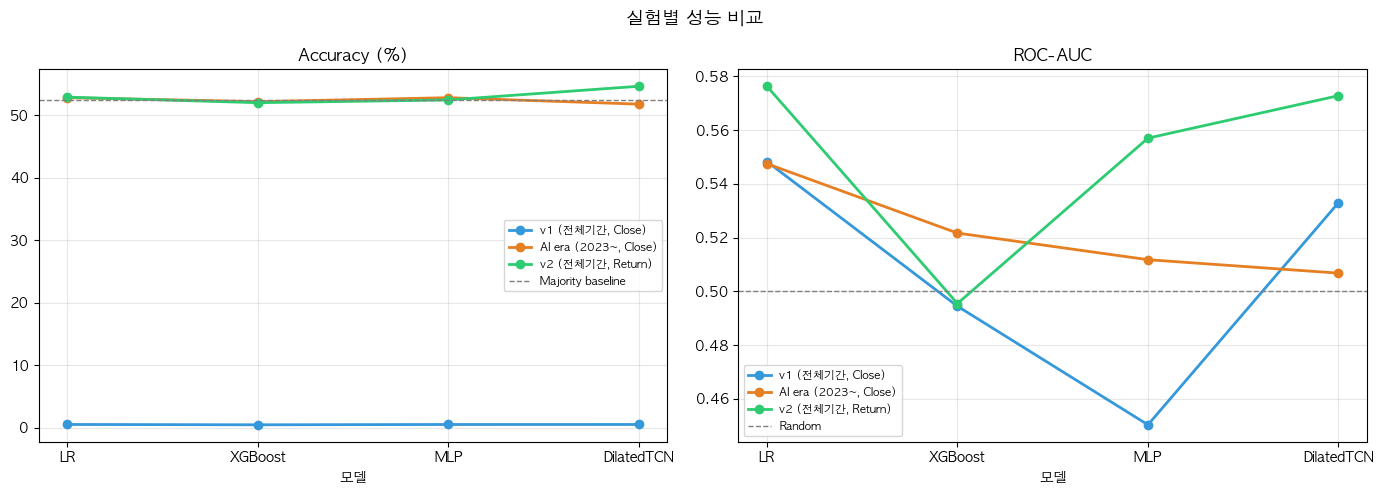

In [7]:
v1  = pd.read_csv(Path("../reports/results/model_metrics.csv"))
ai  = pd.read_csv(Path("../reports/results/ai_era/model_metrics.csv"))
v2  = pd.read_csv(Path("../reports/results/v2/model_metrics.csv"))

v1["실험"]  = "v1 (전체기간, Close)"
ai["실험"] = "AI era (2023~, Close)"
v2["실험"]  = "v2 (전체기간, Return)"

all_exp = pd.concat([v1, ai, v2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [
    (axes[0], "accuracy", "Accuracy (%)"),
    (axes[1], "roc_auc",  "ROC-AUC"),
]:
    for exp, color in [
        ("v1 (전체기간, Close)",   "#3498db"),
        ("AI era (2023~, Close)", "#e67e22"),
        ("v2 (전체기간, Return)",  "#2ecc71"),
    ]:
        sub = all_exp[all_exp["실험"] == exp]
        ax.plot(sub["model"], sub[metric], marker="o", label=exp, color=color, linewidth=2)

    if metric == "accuracy":
        ax.axhline(52.4, color="gray", linestyle="--", linewidth=1, label="Majority baseline")
    else:
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("모델")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("실험별 성능 비교", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "eval_experiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()